# Análise de Consistência de Arquivos WAV com Codificação IMA ADPCM

Este notebook tem como objetivo analisar a integridade e consistência de arquivos de áudio no formato `.WAV` que utilizam a codificação **IMA ADPCM**. Ele verifica se os blocos de dados do áudio estão corretamente encadeados, identificando possíveis corrupções ou erros de gravação.

## O que é IMA ADPCM?

**ADPCM** (Adaptative Differential Pulse-Code Modulation) é um algoritmo de compressão de áudio com perdas. Em vez de armazenar o valor completo de cada amostra de áudio (como no PCM padrão), ele armazena a **diferença** entre a amostra atual e a anterior. Além disso, ele é "adaptativo", o que significa que o passo de quantização (o `step`) se ajusta dinamicamente à complexidade do sinal, permitindo uma compressão mais eficiente.

O padrão **IMA (Interactive Multimedia Association)** é uma implementação específica e comum do ADPCM, usando 4 bits por amostra.

## Como a Verificação de Consistência Funciona?

Um arquivo IMA ADPCM é dividido em **blocos**. Cada bloco contém um pequeno cabeçalho e os dados de áudio comprimidos.

1.  **Cabeçalho do Bloco:** Armazena o valor inicial do preditor (primeira amostra decodificada do bloco) e um `índice` (`step_index`) inicial para a tabela de passos (`StepTab`).
2.  **Processo de Decodificação:** Para cada amostra de 4 bits (nibble) dentro do bloco, o decodificador atualiza o `índice` com base em uma tabela de ajuste (`IndexTab`).
3.  **A Verificação:** O `índice` calculado ao final de um bloco `N` **deve ser idêntico** ao `índice` armazenado no cabeçalho do bloco seguinte, `N+1`.

Se os valores forem diferentes, temos uma **inconsistência**. Isso geralmente indica um erro de escrita, perda de pacotes ou corrupção de dados no arquivo. Este notebook automatiza essa verificação para cada bloco do arquivo.

### 1. Importação das Bibliotecas

Primeiro, importamos todas as bibliotecas necessárias para o nosso trabalho: `numpy` para operações numéricas, `matplotlib` para gráficos, `struct` para ler dados binários, `pandas` para criar relatórios, entre outras.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import struct
from tqdm.auto import tqdm
import pandas as pd
from datetime import datetime

### 2. Leitura do Arquivo WAV

A função `read_wave_ima_adpcm` é responsável por abrir o arquivo `.WAV` em modo binário e ler seu cabeçalho. Ela navega pela estrutura do arquivo (chunks `RIFF`, `WAVE`, `fmt ` e `data`) para extrair metadados essenciais como:

- **Taxa de amostragem (`sample_rate`)**: Quantas amostras de áudio por segundo.
- **Número de canais (`num_channels`)**: Mono (1), Estéreo (2), etc.
- **Alinhamento do Bloco (`block_align`)**: O tamanho de cada bloco de dados em bytes.
- **Amostras por Bloco (`samples_per_block`)**: Quantas amostras de áudio decodificadas um bloco contém.

Ela também valida se o arquivo realmente usa a codificação IMA ADPCM (código `0x0011`).

In [25]:
def read_wave_ima_adpcm(filename):
    """
    Lê arquivo WAV com codificação IMA ADPCM e extrai todos os parâmetros
    """
    print("Lendo arquivo WAV...")
    with open(filename, 'rb') as f:
        # Lê header RIFF
        riff = f.read(4)
        if riff != b'RIFF':
            raise ValueError("Não é um arquivo RIFF válido")
        
        file_size = struct.unpack('<I', f.read(4))[0]
        wave = f.read(4)
        if wave != b'WAVE':
            raise ValueError("Não é um arquivo WAVE válido")
        
        fmt_found = False
        data_found = False
        
        while True:
            chunk_id = f.read(4)
            if len(chunk_id) < 4:
                break
                
            chunk_size = struct.unpack('<I', f.read(4))[0]
            
            if chunk_id == b'fmt ':
                fmt_found = True
                fmt_start = f.tell()
                
                audio_format = struct.unpack('<H', f.read(2))[0]
                num_channels = struct.unpack('<H', f.read(2))[0]
                sample_rate = struct.unpack('<I', f.read(4))[0]
                byte_rate = struct.unpack('<I', f.read(4))[0]
                block_align = struct.unpack('<H', f.read(2))[0]
                bits_per_sample = struct.unpack('<H', f.read(2))[0]
                
                if audio_format != 0x0011:
                    raise ValueError(f"Formato não é IMA ADPCM (código: {audio_format:#x})")
                
                extra_size = struct.unpack('<H', f.read(2))[0]
                samples_per_block = struct.unpack('<H', f.read(2))[0]
                
                print(f"=== Informações do WAV ===")
                print(f"Formato: IMA ADPCM (0x{audio_format:04x})")
                print(f"Canais: {num_channels}")
                print(f"Sample Rate: {sample_rate} Hz")
                print(f"Block Align: {block_align} bytes")
                print(f"Bits per Sample: {bits_per_sample}")
                print(f"Samples per Block: {samples_per_block}")
                print()
                
                f.seek(fmt_start + chunk_size)
                
            elif chunk_id == b'fact':
                num_samples = struct.unpack('<I', f.read(4))[0]
                print(f"Total de samples: {num_samples}")
                if chunk_size > 4:
                    f.read(chunk_size - 4)
                    
            elif chunk_id == b'data':
                data_found = True
                data_size = chunk_size
                
                print(f"Data chunk size: {data_size} bytes")
                print()
                
                audio_data = f.read(data_size)
                break
            else:
                f.seek(chunk_size, 1)
        
        if not fmt_found or not data_found:
            raise ValueError("Chunks necessários não encontrados")
        
        return {
            'num_channels': num_channels,
            'sample_rate': sample_rate,
            'block_align': block_align,
            'samples_per_block': samples_per_block,
            'bits_per_sample': bits_per_sample,
            'audio_data': audio_data,
            'data_size': data_size
        }

### 3. Extração dos Nibbles

Como o IMA ADPCM usa 4 bits para codificar cada amostra, precisamos processar os dados em unidades de 4 bits, conhecidas como **nibbles**. Um byte (8 bits) contém dois nibbles. 

Esta função `extract_nibbles_matlab_style` lê o fluxo de bytes do áudio e o quebra em um array de nibbles. A ordem de extração (nibble baixo primeiro, depois nibble alto) foi definida para replicar o comportamento de uma função específica do MATLAB, garantindo a consistência com análises anteriores.

In [26]:
def extract_nibbles_matlab_style(audio_data):
    """
    Extrai nibbles exatamente como o MATLAB faz com fread(...,'uint4','ieee-be')
    """
    print("Extraindo nibbles...")
    data_array = np.frombuffer(audio_data, dtype=np.uint8)
    
    nibbles = np.empty(len(data_array) * 2, dtype=np.uint8)
    
    # MATLAB 'uint4' com 'ieee-be' lê nibble baixo primeiro, depois alto
    nibbles[0::2] = data_array & 0x0F      # nibble baixo
    nibbles[1::2] = (data_array >> 4) & 0x0F  # nibble alto
    
    return nibbles

### 4. O Coração da Análise: Verificando a Consistência

A função `analyze_single_channel` é onde a mágica acontece. Ela simula o processo de decodificação do IMA ADPCM para um único canal, mas com foco exclusivo no `índice` (`step_index`).

#### Tabelas do IMA ADPCM

- `IndexTab`: Um array usado para ajustar o `índice` atual. O ajuste depende do nibble que está sendo lido. Valores negativos diminuem o `índice`, e positivos o aumentam. A equação é: $$ \text{índice}_{\text{novo}} = \text{índice}_{\text{antigo}} + \text{IndexTab}[\text{nibble}] $$
- `StepTab`: Uma tabela com 89 valores de passos de quantização. O `índice` (que varia de 0 a 88) aponta para um valor nesta tabela. Quanto maior o `índice`, maior o passo, o que é útil para codificar partes do áudio com grande variação (transientes).

#### Processo
A função itera sobre os dados organizados em blocos. 
1.  Para cada bloco, ela processa os nibbles um a um, atualizando o `índice` conforme a regra acima.
2.  No início do bloco seguinte, ela lê o `índice` armazenado no cabeçalho desse novo bloco.
3.  Ela **compara** o `índice` que ela calculou ao final do bloco anterior com o `índice` lido do cabeçalho do bloco atual.
4.  Se houver uma divergência, ela registra uma **inconsistência**, armazenando o instante de tempo, a diferença dos índices e outras informações relevantes.

In [27]:
def analyze_single_channel(c, L, ncanais, samples_per_block, sample_rate, channel):
    """
    Analisa um único canal e retorna resultados (VERSÃO CORRIGIDA PARA MONO/ESTÉREO)
    """
    # Tabelas IMA ADPCM
    IndexTab = np.array([-1, -1, -1, -1, 2, 4, 6, 8, -1, -1, -1, -1, 2, 4, 6, 8], dtype=np.int8)
    StepTab = np.array([
        7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 19, 21, 23, 25, 28, 31, 34, 37, 41, 45,
        50, 55, 60, 66, 73, 80, 88, 97, 107, 118, 130, 143, 157, 173, 190, 209, 230,
        253, 279, 307, 337, 371, 408, 449, 494, 544, 598, 658, 724, 796, 876, 963,
        1060, 1166, 1282, 1411, 1552, 1707, 1878, 2066, 2272, 2499, 2749, 3024, 3327,
        3660, 4026, 4428, 4871, 5358, 5894, 6484, 7132, 7845, 8630, 9493, 10442, 11487,
        12635, 13899, 15289, 16818, 18500, 20350, 22385, 24623, 27086, 29794, 32767
    ], dtype=np.int16)
    
    # Parâmetros
    napcpb = samples_per_block
    nppcpb = ((napcpb - 1) // 8) + 1
    
    # Reshape 1: dados=reshape(c,8,L/8)
    dados = c.reshape(8, L // 8, order='F')
    
    # Seleciona canal
    a = dados[:, channel::ncanais]
    
    # >>>>> INÍCIO DA CORREÇÃO <<<<<
    # O cálculo do número de colunas (L2[1]) agora usa 'ncanais' para ser dinâmico
    num_colunas_reshape = a.shape[1] // (nppcpb * (8 // ncanais) ) if ncanais > 0 else 0
    
    # Verificação de consistência para o reshape
    if a.size != (8 * nppcpb) * num_colunas_reshape:
        # Tenta uma lógica alternativa para o reshape que usa o tamanho de 'a' diretamente
        num_colunas_reshape = a.size // (8 * nppcpb)

    a = a.reshape(8 * nppcpb, num_colunas_reshape, order='F')
    # >>>>> FIM DA CORREÇÃO <<<<<
    
    L2 = a.shape
    
    # Inicialização
    indice = 0
    saida = np.zeros((6, L2[1]))
    armazenaindicesetep = np.zeros((2, napcpb * L // (ncanais * 8 * nppcpb)), dtype=np.int16) # ajustado para ncanais
    minimo = 0
    maximo = 0
    n = 0
    
    # Lista para armazenar detalhes das inconsistências
    inconsistencias_detalhadas = []
    
    # Loop principal
    for j in range(L2[1]):
        indiceinicio = 0
        
        for i in range(L2[0]):
            
            if i == 4 or i == 5:  # Lê o índice do header (ordem correta: LSB, MSB)
                if i == 4:
                    indiceinicio = indiceinicio + int(a[i, j])  # LSB
                else:
                    indiceinicio = int(a[i, j]) * 16 + indiceinicio  # MSB
                    
                    # Verifica inconsistência
                    if indice != indiceinicio:
                        minimo = 0
                        maximo = 0
                        
                        if n >= napcpb:
                            if np.min(armazenaindicesetep[0, n-napcpb:n]) == 0:
                                minimo = -1
                            if np.max(armazenaindicesetep[0, n-napcpb:n]) == 88:
                                maximo = 1
                        
                        saida[:, j] = [1, indice, indiceinicio, indice - indiceinicio, minimo, maximo]
                        
                        # Calcula o instante de tempo da inconsistência
                        sample_number = j * samples_per_block
                        tempo_segundos = sample_number / sample_rate
                        
                        # Formata tempo em HH:MM:SS.mmm
                        horas = int(tempo_segundos // 3600)
                        minutos = int((tempo_segundos % 3600) // 60)
                        segundos = tempo_segundos % 60
                        tempo_formatado = f"{horas:02d}:{minutos:02d}:{segundos:06.3f}"
                        
                        # Armazena detalhes
                        inconsistencias_detalhadas.append({
                            'bloco': j,
                            'sample': sample_number,
                            'tempo_segundos': tempo_segundos,
                            'tempo_formatado': tempo_formatado,
                            'indice_calculado': indice,
                            'indice_header': indiceinicio,
                            'diferenca': indice - indiceinicio,
                            'atingiu_minimo': minimo == -1,
                            'atingiu_maximo': maximo == 1
                        })
                    
                    # Atualiza o índice
                    indice = indiceinicio
                    
                    # Clipping
                    if indice > 88:
                        indice = 88
                    if indice < 0:
                        indice = 0
                    
                    # Armazena
                    if n < armazenaindicesetep.shape[1]:
                        armazenaindicesetep[0, n] = indice
                        armazenaindicesetep[1, n] = StepTab[indice]
                    n = n + 1
                    
            elif i > 7:  # Processa dados ADPCM
                SampxCode = int(a[i, j])
                indice = indice + IndexTab[SampxCode]
                
                # Clipping
                if indice > 88:
                    indice = 88
                if indice < 0:
                    indice = 0
                
                if n < armazenaindicesetep.shape[1]:
                    armazenaindicesetep[0, n] = indice
                    armazenaindicesetep[1, n] = StepTab[indice]
                n = n + 1
    
    return {
        'saida': saida,
        'indices': armazenaindicesetep[:, :n],
        'num_blocos': L2[1],
        'num_samples': n,
        'inconsistencias_detalhadas': inconsistencias_detalhadas
    }

### 5. Funções de Visualização e Relatório

Para facilitar a interpretação dos resultados, temos um conjunto de funções auxiliares:

- `plot_inconsistency_flags`: Gera um gráfico simples que mostra um "pulso" (de 0 para 1) em cada bloco onde uma inconsistência foi detectada. Isso dá uma visão geral e rápida da distribuição dos erros ao longo do arquivo.
- `generate_statistics_report`: Imprime um relatório estatístico detalhado no console, com o número total de inconsistências, percentual, análise das diferenças encontradas e estatísticas sobre o uso dos índices.
- `export_detailed_report`: Cria um arquivo `.csv` contendo uma linha para cada inconsistência encontrada. O relatório inclui o instante exato (timestamp) do erro, facilitando a análise posterior em outras ferramentas.

In [28]:
def plot_inconsistency_flags(resultados_canais):
    """
    Gera visualização APENAS das flags de inconsistência
    """
    num_canais = len(resultados_canais)
    
    if num_canais == 1:
        fig, ax = plt.subplots(1, 1, figsize=(14, 5))
        axes = [ax]
    else:
        fig, axes = plt.subplots(num_canais, 1, figsize=(14, 4 * num_canais))
        if num_canais == 1:
            axes = [axes]
    
    for idx, (channel, resultado) in enumerate(resultados_canais.items()):
        saida = resultado['saida']
        
        axes[idx].plot(saida[0, :], 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f'Canal {channel}: Flags de Inconsistência', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Bloco')
        axes[idx].set_ylabel('Flag (0=OK, 1=Inconsistência)')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim([-0.1, 1.1])
        
        # Adiciona estatística no gráfico
        num_incons = int(np.sum(saida[0, :] == 1))
        num_blocos = saida.shape[1]
        pct = num_incons / num_blocos * 100
        axes[idx].text(0.02, 0.98, f'Inconsistências: {num_incons} ({pct:.2f}%)', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

def generate_statistics_report(resultados_canais, wav_info):
    """
    Gera relatório estatístico completo
    """
    print("\n" + "="*70)
    print("RELATÓRIO ESTATÍSTICO DE CONSISTÊNCIA IMA ADPCM")
    print("="*70)
    print(f"\nArquivo analisado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Sample Rate: {wav_info['sample_rate']} Hz")
    print(f"Samples per Block: {wav_info['samples_per_block']}")
    print(f"Block Align: {wav_info['block_align']} bytes")
    print("\n" + "-"*70)
    
    for channel, resultado in resultados_canais.items():
        saida = resultado['saida']
        indices = resultado['indices']
        num_blocos = resultado['num_blocos']
        num_samples = resultado['num_samples']
        inconsistencias = resultado['inconsistencias_detalhadas']
        
        blocos_com_flag = saida[0, :] == 1
        num_inconsistencias = np.sum(blocos_com_flag)
        
        print(f"\nCANAL {channel}:")
        print(f"  Total de blocos: {num_blocos:,}")
        print(f"  Total de samples: {num_samples:,}")
        print(f"  Duração: {num_samples / wav_info['sample_rate']:.2f} segundos")
        print(f"\n  INCONSISTÊNCIAS:")
        print(f"    Total: {num_inconsistencias} ({num_inconsistencias/num_blocos*100:.2f}%)")
        
        if num_inconsistencias > 0:
            blocos_min = int(np.sum(saida[4, blocos_com_flag] == -1))
            blocos_max = int(np.sum(saida[5, blocos_com_flag] == 1))
            
            print(f"    Blocos que atingiram mínimo (0): {blocos_min}")
            print(f"    Blocos que atingiram máximo (88): {blocos_max}")
            
            # Diferenças
            diferencas = saida[3, blocos_com_flag]
            print(f"\n  ANÁLISE DAS DIFERENÇAS:")
            print(f"    Diferença média: {np.mean(diferencas):.2f}")
            print(f"    Diferença mínima: {np.min(diferencas):.0f}")
            print(f"    Diferença máxima: {np.max(diferencas):.0f}")
            print(f"    Desvio padrão: {np.std(diferencas):.2f}")
            
            # Primeiras e últimas inconsistências
            if len(inconsistencias) > 0:
                primeira = inconsistencias[0]
                ultima = inconsistencias[-1]
                print(f"\n  LOCALIZAÇÃO TEMPORAL:")
                print(f"    Primeira inconsistência: {primeira['tempo_formatado']} (bloco {primeira['bloco']})")
                print(f"    Última inconsistência: {ultima['tempo_formatado']} (bloco {ultima['bloco']})")
        else:
            print(f"    ✓ Nenhuma inconsistência detectada!")
        
        print(f"\n  ESTATÍSTICAS DOS ÍNDICES:")
        print(f"    Mínimo: {int(np.min(indices[0, :]))}")
        print(f"    Máximo: {int(np.max(indices[0, :]))}")
        print(f"    Média: {np.mean(indices[0, :]):.2f}")
        print(f"    Mediana: {np.median(indices[0, :]):.2f}")
        print(f"    Desvio padrão: {np.std(indices[0, :]):.2f}")
        
        print("\n" + "-"*70)

def export_detailed_report(resultados_canais, wav_info, original_filename):
    """
    Exporta relatório detalhado em CSV com timestamps
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    base_filename = original_filename.rsplit('.', 1)[0]
    
    for channel, resultado in resultados_canais.items():
        inconsistencias = resultado['inconsistencias_detalhadas']
        
        if len(inconsistencias) > 0:
            df = pd.DataFrame(inconsistencias)
            
            # Reordena colunas para melhor visualização
            colunas_ordenadas = [
                'bloco', 
                'tempo_formatado', 
                'tempo_segundos', 
                'sample',
                'indice_calculado', 
                'indice_header', 
                'diferenca',
                'atingiu_minimo', 
                'atingiu_maximo'
            ]
            df = df[colunas_ordenadas]
            
            output_file = f"{base_filename}_canal{channel}_inconsistencias_{timestamp}.csv"
            df.to_csv(output_file, index=False)
            print(f"  Canal {channel}: {output_file} ({len(inconsistencias)} inconsistências)")
        else:
            print(f"  Canal {channel}: Nenhuma inconsistência para exportar")

### 6. Função Principal (Wrapper)

A função `check_ima_adpcm_consistency_full` organiza todo o processo. Ela chama as funções na ordem correta: lê o arquivo, extrai os nibbles, analisa cada canal, gera os gráficos e relatórios, e exporta os dados.

In [29]:
def check_ima_adpcm_consistency_full(filename, analyze_all_channels=True, export_report=True):
    """
    Análise completa de consistência IMA ADPCM
    
    Parameters:
    -----------
    filename : str
        Nome do arquivo WAV
    analyze_all_channels : bool
        Se True, analisa todos os canais. Se False, apenas canal 0
    export_report : bool
        Se True, exporta relatório em CSV
    """
    
    # Lê arquivo WAV
    wav_info = read_wave_ima_adpcm(filename)
    
    ncanais = wav_info['num_channels']
    samples_per_block = wav_info['samples_per_block']
    sample_rate = wav_info['sample_rate']
    audio_data = wav_info['audio_data']
    
    # Extrai nibbles
    c = extract_nibbles_matlab_style(audio_data)
    L = len(c)
    
    print(f"=== Processamento ===")
    print(f"Total de nibbles: {L:,}")
    print(f"Número de canais: {ncanais}")
    print()
    
    # Analisa canais
    resultados_canais = {}
    
    if analyze_all_channels:
        canais_analisar = range(ncanais)
    else:
        canais_analisar = [0]
    
    for channel in canais_analisar:
        print(f"Processando Canal {channel}...")
        resultado = analyze_single_channel(c, L, ncanais, samples_per_block, sample_rate, channel)
        resultados_canais[channel] = resultado
    
    # Gera gráfico apenas das flags de inconsistência
    print("\nGerando visualização das inconsistências...")
    plot_inconsistency_flags(resultados_canais)
    
    # Gera relatório estatístico
    print("\nGerando relatório estatístico...")
    generate_statistics_report(resultados_canais, wav_info)
    
    # Exporta relatório detalhado
    if export_report:
        print("\nExportando relatório detalhado...")
        export_detailed_report(resultados_canais, wav_info, filename)
        
    return resultados_canais

### 7. Execução da Análise

Agora, vamos executar a análise. 

**Instruções:**
1.  Coloque o arquivo `.WAV` que você deseja analisar na mesma pasta que este notebook.
2.  Altere o nome do arquivo na string abaixo (por exemplo, de `'PR2 A 13032017.WAV'` para `'meu_arquivo.wav'`).
3.  Execute a célula de código a seguir.

A análise será iniciada e, ao final, você verá os gráficos, um relatório no console e um arquivo `.csv` será salvo na pasta caso inconsistências sejam encontradas.

Lendo arquivo WAV...
=== Informações do WAV ===
Formato: IMA ADPCM (0x0011)
Canais: 1
Sample Rate: 8000 Hz
Block Align: 512 bytes
Bits per Sample: 4
Samples per Block: 1017

Total de samples: 637659
Data chunk size: 464384 bytes

Extraindo nibbles...
=== Processamento ===
Total de nibbles: 928,768
Número de canais: 1

Processando Canal 0...

Gerando visualização das inconsistências...


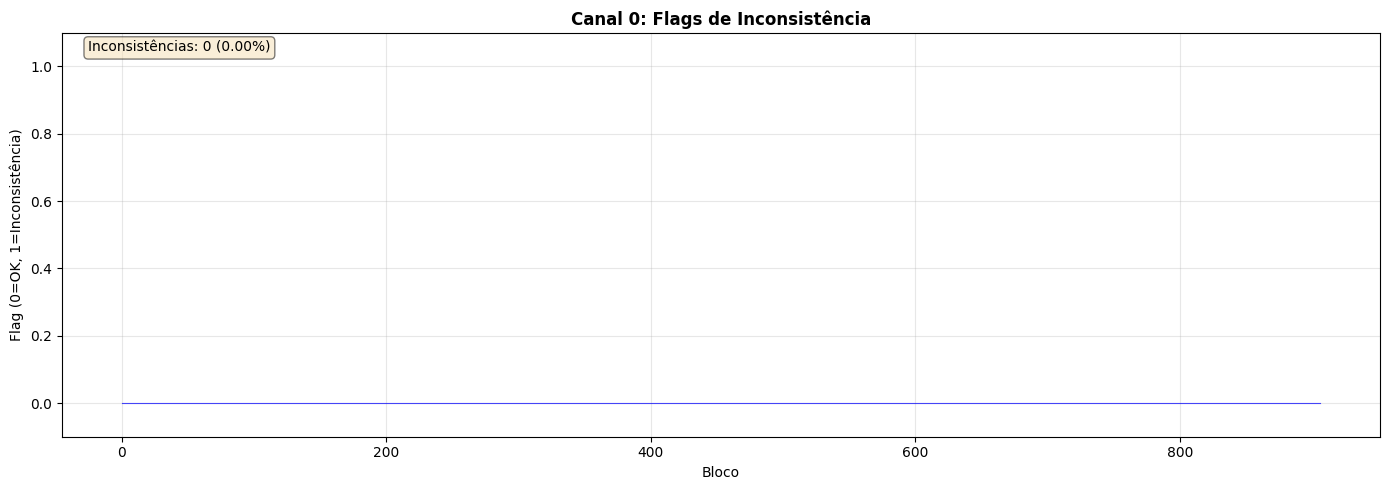


Gerando relatório estatístico...

RELATÓRIO ESTATÍSTICO DE CONSISTÊNCIA IMA ADPCM

Arquivo analisado em: 2025-10-06 07:17:28
Sample Rate: 8000 Hz
Samples per Block: 1017
Block Align: 512 bytes

----------------------------------------------------------------------

CANAL 0:
  Total de blocos: 907
  Total de samples: 922,419
  Duração: 115.30 segundos

  INCONSISTÊNCIAS:
    Total: 0 (0.00%)
    ✓ Nenhuma inconsistência detectada!

  ESTATÍSTICAS DOS ÍNDICES:
    Mínimo: 0
    Máximo: 88
    Média: 48.08
    Mediana: 48.00
    Desvio padrão: 8.84

----------------------------------------------------------------------

Exportando relatório detalhado...
  Canal 0: Nenhuma inconsistência para exportar


In [34]:
# === CONFIGURAÇÃO DA ANÁLISE ===

# Coloque o nome do seu arquivo WAV aqui
nome_do_arquivo = 'Dep.Almerinda solicita extratos.WAV'

# Descomente a linha abaixo para executar a análise
try:
     resultados = check_ima_adpcm_consistency_full(
         nome_do_arquivo, 
         analyze_all_channels=True,
         export_report=True
     )
except FileNotFoundError:
     print(f'\n[ERRO] Arquivo não encontrado: "{nome_do_arquivo}"\nPor favor, verifique se o nome está correto e se o arquivo está na mesma pasta do notebook.')
except ValueError as e:
     print(f'\n[ERRO] Ocorreu um problema ao ler o arquivo: {e}')
